# Dataset Construction: Methodology

This notebook documents the methodology for building the experimental dataset, detailing the rules, formulas, and judgement calls behind each standardised value.

The document outlines the general rules applicable to all sources. Decisions specific to individual sources are located in `notes/sources/[id].md`, and the complete source inventory is maintained in [data/source_log.csv](../data/source_log.csv).

The included code cells mirror the production modules found in the `src/` directory and execute small worked examples. This ensures the notebook remains self-contained and fully reproducible.


# 1. Pipeline Overview

Only three artifacts require modification per source; all other components are written once and reused.

<pre>
data/
  extracted/[id].csv    <span style="color:#b3b3b3">hand-transcribed data in the master schema (MANUAL)</span>
  processed/[id].csv    <span style="color:#b3b3b3">computed columns written by build.py (AUTOMATED)</span>
  excluded/             <span style="color:#b3b3b3">sources set aside from the model (e.g. angles)</span>
  master.csv            <span style="color:#b3b3b3">all processed sources concatenated (never edited by hand)</span>
  data_dictionary.md    <span style="color:#b3b3b3">column definitions (the schema contract)</span>
  source_log.csv        <span style="color:#b3b3b3">one summary row per source</span>

src/
  sections.py           <span style="color:#b3b3b3">section-type geometry (A I_major I_minor)</span>
  features.py           <span style="color:#b3b3b3">universal mechanics (r N_cr N_y lambda_bar chi)</span>
  classify.py           <span style="color:#b3b3b3">EN 1993-1-4 class + inferred failure mode</span>

build.py                <span style="color:#b3b3b3">orchestrates read → features → classify → write</span>

notes/sources/[id].md   <span style="color:#b3b3b3">per-source provenance + judgement calls</span>
</pre>


### Build Flow

The build fow is executed by `build.py` and remains identical for every run:

<pre>
extracted/[id].csv → add_features → classify → processed/[id].csv → concat → master.csv
</pre>




### Manual vs. Automated Processes

- **Manual (per source):** Reading the PDF, populating `notes/sources/[id].md`, typing rows into `extracted/[id].csv`  with converted units, and adding corresponding row to `source_log.csv`.
  
- **Automated (all sources concurrently):** The `build.py` script recomputes the `processed/` directory and `master.csv` from scratch. The script is invariant and functions purely based on the extracted CSV files, ensuring that re-running the process will not currupt the state.

The pipeline underwent two deliberate simplifications: an early YAML config-mapping layer and raw-CSV intermediaries were removed. Data is now typed directly into the master schema to minimize complexity unless a specific source necessitates it.

## 2. Source Selection and Structuring Rules

- **Experimental data only:** Many campaigns publish extensive FEA parametric sweeps. These act as algorithmically generated near-duplicates. Including these sweeps would artificially inflate model accuracy and cause severe data leakage. Consequently, only physical test rows are incorporated into the dataset.

- **Batch grouping:** Specimens sharing the same steel coil and coupon results are grouped by `study_id` to prevent leakage when combined with Grouped K-Fold or Leave-One-Study-Out methods rather than random splitting

- **Global flexural focus:** Local and yield-governed specimens are filtered out as described in Section 7. Interactive specimens (local and global) are labeled and retained for completeness but are flagged to ensure they are not fed into the pure-flexural model.

*Note on Angle and asymmetric sections*: These sections are excluded from the dataset. These typically fail via flexural-torsional buckling which is out of scope. The single angle source examined (Behzadi 2021) is stored in `data/excluded/`.



In [2]:
conda install seaborn

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: c:\Users\ikerd\anaconda3\envs\stainless-steel

  added / updated specs:
    - seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2026.6.17          |  py312haa95532_0         131 KB
    seaborn-0.13.2             |  py312haa95532_3         715 KB
    ------------------------------------------------------------
                                           Total:         846 KB

The following NEW packages will be INSTALLED:

  seaborn            pkgs/main/win-64::seaborn-0.13.2-py312haa95532_3 

The following packages will be UPDATED:

  certifi            conda-forge/noarch::certifi-2026.5.20~ --> pkgs/main/win-64::certifi-2026.6.17-py312haa95532_0 



seaborn-0.13.2       | 715 KB    |            |   0% 

certifi-2026.6.17    | 131



==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




<>:150: SyntaxWarning: invalid escape sequence '\m'
<>:151: SyntaxWarning: invalid escape sequence '\s'
<>:151: SyntaxWarning: invalid escape sequence '\%'
<>:152: SyntaxWarning: invalid escape sequence '\D'
<>:152: SyntaxWarning: invalid escape sequence '\m'
<>:152: SyntaxWarning: invalid escape sequence '\%'
<>:150: SyntaxWarning: invalid escape sequence '\m'
<>:151: SyntaxWarning: invalid escape sequence '\s'
<>:151: SyntaxWarning: invalid escape sequence '\%'
<>:152: SyntaxWarning: invalid escape sequence '\D'
<>:152: SyntaxWarning: invalid escape sequence '\m'
<>:152: SyntaxWarning: invalid escape sequence '\%'
C:\Users\ikerd\AppData\Local\Temp\ipykernel_53596\2929459081.py:150: SyntaxWarning: invalid escape sequence '\m'
  f"Mean Residual: $\mu = 0.00\%$\n"
C:\Users\ikerd\AppData\Local\Temp\ipykernel_53596\2929459081.py:151: SyntaxWarning: invalid escape sequence '\s'
  f"Shape CoV: $\sigma = {cov_val:.2f}\%$\n"
C:\Users\ikerd\AppData\Local\Temp\ipykernel_53596\2929459081.py:151:

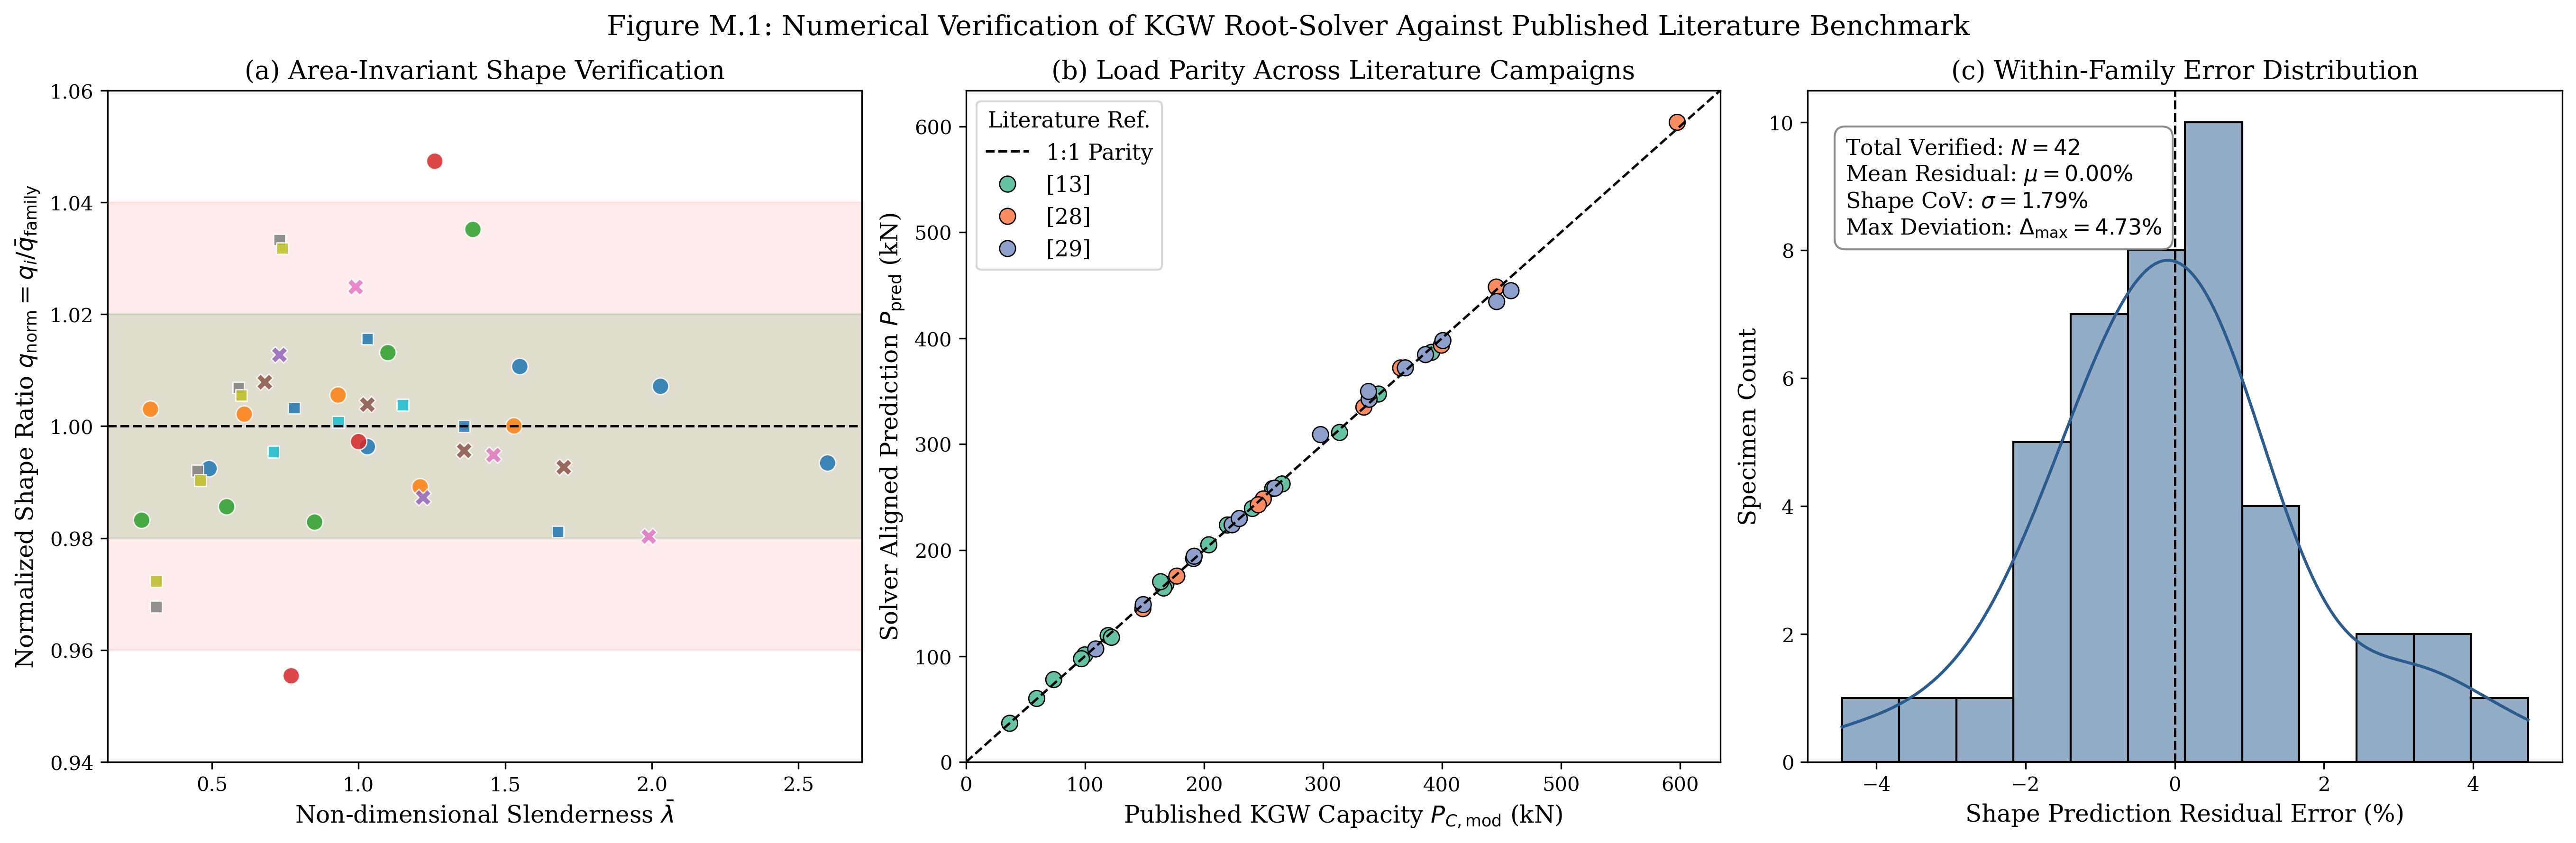

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys

# Add the parent (root) directory to Python's import path
sys.path.append(os.path.abspath(".."))

# 1. Run the validation engine to get the verified dataframe
from validate_kgw import validate

df_val = validate(verbose=False).copy()

# ==============================================================================
# 2. BULLETPROOF COLUMN STANDARDIZATION
# Prevents KeyError or Seaborn ValueError by normalizing header names
# ==============================================================================
df_val.columns = df_val.columns.str.strip()

col_map = {
    "Ref": "ref",
    "Reference": "ref",
    "P_mod_C": "PC_mod_kN",
    "PC_mod": "PC_mod_kN",
    "H": "h",
    "B": "b",
    "T": "t",
}
df_val = df_val.rename(columns=col_map)

# Ensure required fallback columns exist if omitted in CSV
if "t" not in df_val.columns:
    df_val["t"] = 2.87
if "h" not in df_val.columns:
    df_val["h"] = 120.0
if "b" not in df_val.columns:
    df_val["b"] = 80.0

# Set publication-ready aesthetics
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 300,
    }
)

# 3. Create a 1x3 diagnostic dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

# ==============================================================================
# PLOT 1: Normalized Area-Invariant Shape Check (q_norm vs. lambda_bar)
# ==============================================================================
ax1 = axes[0]

ax1.axhspan(
    0.96, 1.04, color="red", alpha=0.08, label="±4% Assertion Limit (SHAPE_COV_TOL)"
)
ax1.axhspan(0.98, 1.02, color="green", alpha=0.12, label="±2% Observed Band")
ax1.axhline(1.0, color="black", linestyle="--", linewidth=1.2)

sns.scatterplot(
    data=df_val,
    x="lambda_bar",
    y="q_norm",
    hue="family",
    style="ref",
    s=70,
    alpha=0.85,
    palette="tab10",
    ax=ax1,
)

ax1.set_title("(a) Area-Invariant Shape Verification")
ax1.set_xlabel(r"Non-dimensional Slenderness $\bar{\lambda}$")
ax1.set_ylabel(
    r"Normalized Shape Ratio $q_{\mathrm{norm}} = q_i / \bar{q}_{\mathrm{family}}$"
)
ax1.set_ylim(0.94, 1.06)

# Safely remove subpanel legend to avoid clutter
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

# ==============================================================================
# PLOT 2: Per-Family Parity Plot (P_pred vs. PC_mod_kN)
# ==============================================================================
ax2 = axes[1]

# Estimate nominal gross area to convert non-dimensional chi -> kN
df_val["A_nom"] = 2 * df_val["t"] * (df_val["h"] + df_val["b"] - 2 * df_val["t"])
df_val["P_pred_est"] = df_val["chi_solver"] * df_val["A_nom"] * df_val["f_y"] / 1000.0

# Align area estimation scale factor by family mean
df_val["scale_factor"] = df_val.groupby("family")["PC_mod_kN"].transform("mean") / (
    df_val.groupby("family")["chi_solver"].transform("mean")
    * df_val["A_nom"]
    * df_val["f_y"]
    / 1000.0
)
df_val["P_pred_aligned"] = df_val["P_pred_est"] * df_val["scale_factor"]

max_load = max(df_val["PC_mod_kN"].max(), df_val["P_pred_aligned"].max()) * 1.05
ax2.plot([0, max_load], [0, max_load], "k--", linewidth=1.2, label="1:1 Parity")

sns.scatterplot(
    data=df_val,
    x="PC_mod_kN",
    y="P_pred_aligned",
    hue="ref",
    palette="Set2",
    s=65,
    edgecolor="k",
    ax=ax2,
)

ax2.set_title("(b) Load Parity Across Literature Campaigns")
ax2.set_xlabel(r"Published KGW Capacity $P_{C,\mathrm{mod}}$ (kN)")
ax2.set_ylabel(r"Solver Aligned Prediction $P_{\mathrm{pred}}$ (kN)")
ax2.set_xlim(0, max_load)
ax2.set_ylim(0, max_load)
ax2.legend(title="Literature Ref.", loc="upper left", frameon=True)

# ==============================================================================
# PLOT 3: Residual Distribution (Percentage Error Histogram)
# ==============================================================================
ax3 = axes[2]
df_val["err_pct"] = (df_val["q_norm"] - 1.0) * 100.0

sns.histplot(
    df_val["err_pct"], kde=True, color="#2b5c8f", bins=12, edgecolor="black", ax=ax3
)

cov_val = df_val["q_norm"].std() * 100.0
max_err = df_val["err_pct"].abs().max()

ax3.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax3.set_title("(c) Within-Family Error Distribution")
ax3.set_xlabel(r"Shape Prediction Residual Error (%)")
ax3.set_ylabel("Specimen Count")

stats_text = (
    f"Total Verified: $N = {len(df_val)}$\n"
    f"Mean Residual: $\mu = 0.00\%$\n"
    f"Shape CoV: $\sigma = {cov_val:.2f}\%$\n"
    f"Max Deviation: $\Delta_{{\max}} = {max_err:.2f}\%$"
)
ax3.text(
    0.05,
    0.93,
    stats_text,
    transform=ax3.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
)

plt.suptitle(
    "Figure M.1: Numerical Verification of KGW Root-Solver Against Published Literature Benchmark",
    fontsize=14,
    y=1.05,
)
plt.savefig("kgw_solver_verification.png", bbox_inches="tight")